In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

df = pd.read_csv("C:/Users/Joan/Desktop/TFG/db/SP1.csv")

print(df.shape)
print(df.columns.tolist())

(380, 119)
['Div', 'Date', 'Time', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG', 'HTR', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR', 'B365H', 'B365D', 'B365A', 'BWH', 'BWD', 'BWA', 'BFH', 'BFD', 'BFA', 'PSH', 'PSD', 'PSA', 'WHH', 'WHD', 'WHA', '1XBH', '1XBD', '1XBA', 'MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA', 'BFEH', 'BFED', 'BFEA', 'B365>2.5', 'B365<2.5', 'P>2.5', 'P<2.5', 'Max>2.5', 'Max<2.5', 'Avg>2.5', 'Avg<2.5', 'BFE>2.5', 'BFE<2.5', 'AHh', 'B365AHH', 'B365AHA', 'PAHH', 'PAHA', 'MaxAHH', 'MaxAHA', 'AvgAHH', 'AvgAHA', 'BFEAHH', 'BFEAHA', 'B365CH', 'B365CD', 'B365CA', 'BWCH', 'BWCD', 'BWCA', 'BFCH', 'BFCD', 'BFCA', 'PSCH', 'PSCD', 'PSCA', 'WHCH', 'WHCD', 'WHCA', '1XBCH', '1XBCD', '1XBCA', 'MaxCH', 'MaxCD', 'MaxCA', 'AvgCH', 'AvgCD', 'AvgCA', 'BFECH', 'BFECD', 'BFECA', 'B365C>2.5', 'B365C<2.5', 'PC>2.5', 'PC<2.5', 'MaxC>2.5', 'MaxC<2.5', 'AvgC>2.5', 'AvgC<2.5', 'BFEC>2.5', 'BFEC<2.5', 'AHCh', 'B365CAHH', 'B365CAHA', 'PCAHH', 'PCAHA',

In [2]:
cols = [
    "Date",
    "HomeTeam",
    "AwayTeam",
    "FTHG",
    "FTAG",
    "FTR",
    "HS",
    "AS",
    "HST",
    "AST",
    "HC",
    "AC",
    "HY",
    "AY",
    "HR",
    "AR",
    "AvgH",
    "AvgD",
    "AvgA"
]

df = df[cols].copy()
df.dropna(inplace=True)

df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
df = df.sort_values("Date").reset_index(drop=True)

df.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HS,AS,HST,AST,HC,AC,HY,AY,HR,AR,AvgH,AvgD,AvgA
0,2024-08-15,Ath Bilbao,Getafe,1,1,D,7,9,4,2,5,6,4,1,0,0,1.51,4.04,7.61
1,2024-08-15,Betis,Girona,1,1,D,19,13,4,2,4,4,2,0,0,0,2.40,3.38,3.02
2,2024-08-16,Celta,Alaves,2,1,H,6,10,4,2,3,3,3,2,0,0,2.03,3.32,4.02
3,2024-08-16,Las Palmas,Sevilla,2,2,D,13,16,5,5,6,3,0,0,0,0,2.83,3.21,2.65
4,2024-08-17,Osasuna,Leganes,1,1,D,16,10,5,4,6,4,3,2,0,0,1.88,3.44,4.48


In [3]:
df["Date"] = pd.to_datetime(
    df["Date"],
    dayfirst=True
)

df = df.sort_values(
    "Date"
).reset_index(drop=True)

In [4]:
from collections import defaultdict


In [5]:
LAST_N = 5

team_history = defaultdict(list)

features = []

In [6]:
def rolling_mean(values, n=LAST_N):

    if len(values) == 0:
        return np.nan

    return np.mean(values[-n:])

In [7]:
for _, row in df.iterrows():

    home = row["HomeTeam"]
    away = row["AwayTeam"]

    home_hist = team_history[home]
    away_hist = team_history[away]

    feature_row = {

        "Date": row["Date"],

        "HomeTeam": home,
        "AwayTeam": away,

        "HomeGoals5":
            rolling_mean(
                [x["GoalsScored"] for x in home_hist]
            ),

        "AwayGoals5":
            rolling_mean(
                [x["GoalsScored"] for x in away_hist]
            ),

        "HomeConceded5":
            rolling_mean(
                [x["GoalsConceded"] for x in home_hist]
            ),

        "AwayConceded5":
            rolling_mean(
                [x["GoalsConceded"] for x in away_hist]
            ),

        "HomeShots5":
            rolling_mean(
                [x["Shots"] for x in home_hist]
            ),

        "AwayShots5":
            rolling_mean(
                [x["Shots"] for x in away_hist]
            ),

        "HomeShotsTarget5":
            rolling_mean(
                [x["ShotsTarget"] for x in home_hist]
            ),

        "AwayShotsTarget5":
            rolling_mean(
                [x["ShotsTarget"] for x in away_hist]
            ),

        "HomeCorners5":
            rolling_mean(
                [x["Corners"] for x in home_hist]
            ),

        "AwayCorners5":
            rolling_mean(
                [x["Corners"] for x in away_hist]
            ),

        "HomeYellow5":
            rolling_mean(
                [x["Yellow"] for x in home_hist]
            ),

        "AwayYellow5":
            rolling_mean(
                [x["Yellow"] for x in away_hist]
            ),

        "FTHG": row["FTHG"],
        "FTAG": row["FTAG"]
    }

    features.append(feature_row)

    team_history[home].append({

        "GoalsScored": row["FTHG"],
        "GoalsConceded": row["FTAG"],

        "Shots": row["HS"],
        "ShotsTarget": row["HST"],

        "Corners": row["HC"],

        "Yellow": row["HY"]
    })

    team_history[away].append({

        "GoalsScored": row["FTAG"],
        "GoalsConceded": row["FTHG"],

        "Shots": row["AS"],
        "ShotsTarget": row["AST"],

        "Corners": row["AC"],

        "Yellow": row["AY"]
    })

In [8]:
feature_df = pd.DataFrame(features)

feature_df.head()

,Date,HomeTeam,AwayTeam,HomeGoals5,AwayGoals5,HomeConceded5,AwayConceded5,HomeShots5,AwayShots5,HomeShotsTarget5,AwayShotsTarget5,HomeCorners5,AwayCorners5,HomeYellow5,AwayYellow5,FTHG,FTAG
0,2024-08-15,Ath Bilbao,Getafe,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1
1,2024-08-15,Betis,Girona,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1
2,2024-08-16,Celta,Alaves,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,1
3,2024-08-16,Las Palmas,Sevilla,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2
4,2024-08-17,Osasuna,Leganes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1


In [9]:
feature_df = feature_df.dropna()

In [10]:
from sklearn.linear_model import LinearRegression

In [11]:
X = feature_df[[
    "HomeGoals5",
    "AwayGoals5",

    "HomeConceded5",
    "AwayConceded5",

    "HomeShots5",
    "AwayShots5",

    "HomeShotsTarget5",
    "AwayShotsTarget5",

    "HomeCorners5",
    "AwayCorners5",

    "HomeYellow5",
    "AwayYellow5"
]]


In [12]:
y_home = feature_df["FTHG"]
y_away = feature_df["FTAG"]

In [13]:
split = int(
    0.7 * len(feature_df)
)

In [14]:
X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_home_train = y_home.iloc[:split]
y_home_test = y_home.iloc[split:]

y_away_train = y_away.iloc[:split]
y_away_test = y_away.iloc[split:]

In [15]:
home_model = LinearRegression()
away_model = LinearRegression()

home_model.fit(
    X_train,
    y_home_train
)

away_model.fit(
    X_train,
    y_away_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](12,)","[0.05,0.31,0.01,...,0.05,0.09,0.08]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](12,)","['HomeGoals5','AwayGoals5','HomeConceded5',...,'AwayCorners5', 'HomeYellow5','AwayYellow5']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.3886
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,12
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,12


In [16]:
home_pred = home_model.predict(
    X_test
)

away_pred = away_model.predict(
    X_test
)

In [17]:
from sklearn.metrics import mean_absolute_error

In [18]:
print(
    "Home MAE:",
    mean_absolute_error(
        y_home_test,
        home_pred
    )
)

print(
    "Away MAE:",
    mean_absolute_error(
        y_away_test,
        away_pred
    )
)

Home MAE: 0.9818191993470794
Away MAE: 0.8779435543296734


In [19]:
coef_home = pd.Series(
    home_model.coef_,
    index=X.columns
)

coef_home.sort_values(
    key=abs,
    ascending=False
)

HomeGoals5          0.201596
AwayConceded5       0.142559
HomeYellow5        -0.111760
HomeCorners5        0.092418
AwayCorners5       -0.088883
AwayGoals5         -0.082937
HomeShots5          0.058840
AwayShotsTarget5   -0.057321
AwayShots5         -0.033075
AwayYellow5        -0.024606
HomeShotsTarget5   -0.016065
HomeConceded5       0.006698
dtype: float64

In [20]:
coef_away = pd.Series(
    away_model.coef_,
    index=X.columns
)

coef_away.sort_values(
    key=abs,
    ascending=False
)

AwayGoals5          0.311804
AwayConceded5      -0.115485
HomeYellow5         0.094453
AwayYellow5         0.080183
AwayShotsTarget5    0.068424
HomeCorners5       -0.056496
AwayCorners5        0.053200
HomeGoals5          0.046261
HomeShots5         -0.024553
HomeShotsTarget5    0.007970
HomeConceded5       0.005022
AwayShots5         -0.002630
dtype: float64

In [21]:
corr = X.corr()

corr

,HomeGoals5,AwayGoals5,HomeConceded5,AwayConceded5,HomeShots5,AwayShots5,HomeShotsTarget5,AwayShotsTarget5,HomeCorners5,AwayCorners5,HomeYellow5,AwayYellow5
HomeGoals5,1.000000,-0.014132,-0.139938,-0.026481,0.490392,0.044298,0.693203,-0.016294,0.269702,-0.024653,-0.196110,0.006599
AwayGoals5,-0.014132,1.000000,-0.025648,-0.147114,-0.032162,0.490658,-0.031692,0.697004,-0.047502,0.270689,-0.012578,-0.220631
HomeConceded5,-0.139938,-0.025648,1.000000,0.037090,-0.276376,-0.015853,-0.200920,0.004314,-0.209107,0.013573,0.133132,-0.005978
AwayConceded5,-0.026481,-0.147114,0.037090,1.000000,-0.059522,-0.270490,-0.108805,-0.211907,-0.079544,-0.142407,0.039025,0.139432
HomeShots5,0.490392,-0.032162,-0.276376,-0.059522,1.000000,0.081021,0.785551,0.007092,0.654859,0.045874,-0.243160,-0.073647
AwayShots5,0.044298,0.490658,-0.015853,-0.270490,0.081021,1.000000,0.032005,0.793620,0.055676,0.653947,-0.036456,-0.218504
HomeShotsTarget5,0.693203,-0.031692,-0.200920,-0.108805,0.785551,0.032005,1.000000,-0.032782,0.520449,0.006416,-0.282012,-0.073699
AwayShotsTarget5,-0.016294,0.697004,0.004314,-0.211907,0.007092,0.793620,-0.032782,1.000000,0.005313,0.565814,-0.023626,-0.244536
HomeCorners5,0.269702,-0.047502,-0.209107,-0.079544,0.654859,0.055676,0.520449,0.005313,1.000000,0.023417,-0.251945,-0.039651
AwayCorners5,-0.024653,0.270689,0.013573,-0.142407,0.045874,0.653947,0.006416,0.565814,0.023417,1.000000,-0.025818,-0.198164


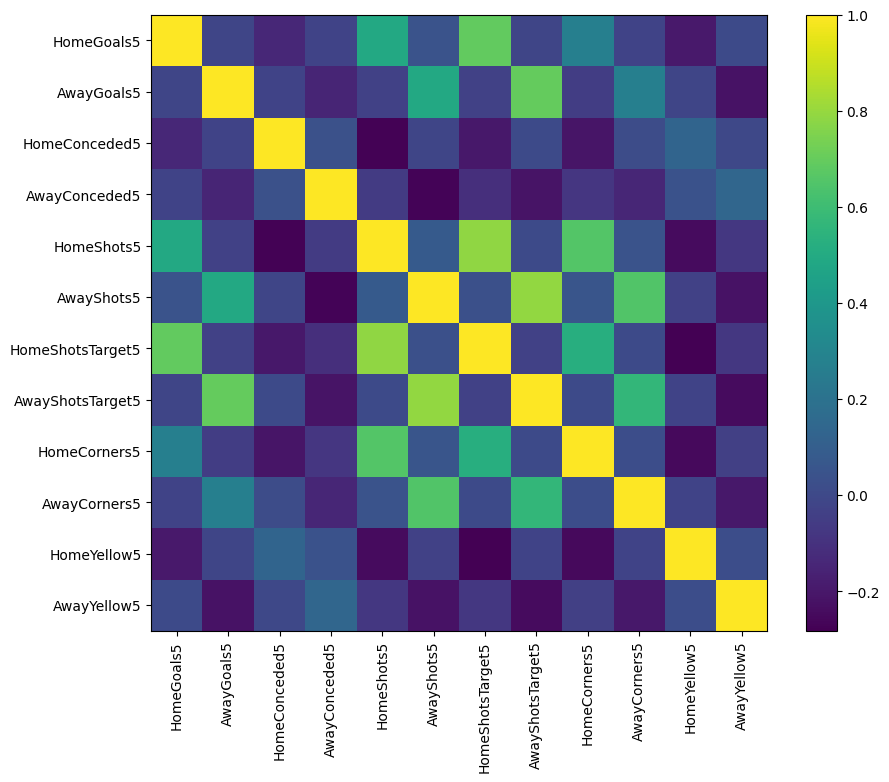

In [22]:
plt.figure(figsize=(10,8))

plt.imshow(corr)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.show()

In [23]:
def build_features(df, last_n):

    def rolling_mean(values):

        if len(values) == 0:
            return np.nan

        return np.mean(values[-last_n:])

    team_history = defaultdict(list)

    features = []

    for _, row in df.iterrows():

        home = row["HomeTeam"]
        away = row["AwayTeam"]

        home_hist = team_history[home]
        away_hist = team_history[away]

        feature_row = {

            "HomeGoals":
                rolling_mean([x["GoalsScored"] for x in home_hist]),

            "AwayGoals":
                rolling_mean([x["GoalsScored"] for x in away_hist]),

            "HomeConceded":
                rolling_mean([x["GoalsConceded"] for x in home_hist]),

            "AwayConceded":
                rolling_mean([x["GoalsConceded"] for x in away_hist]),

            "HomeShots":
                rolling_mean([x["Shots"] for x in home_hist]),

            "AwayShots":
                rolling_mean([x["Shots"] for x in away_hist]),

            "HomeShotsTarget":
                rolling_mean([x["ShotsTarget"] for x in home_hist]),

            "AwayShotsTarget":
                rolling_mean([x["ShotsTarget"] for x in away_hist]),

            "HomeCorners":
                rolling_mean([x["Corners"] for x in home_hist]),

            "AwayCorners":
                rolling_mean([x["Corners"] for x in away_hist]),

            "HomeYellow":
                rolling_mean([x["Yellow"] for x in home_hist]),

            "AwayYellow":
                rolling_mean([x["Yellow"] for x in away_hist]),

            "FTHG": row["FTHG"],
            "FTAG": row["FTAG"]
        }

        features.append(feature_row)

        team_history[home].append({

            "GoalsScored": row["FTHG"],
            "GoalsConceded": row["FTAG"],
            "Shots": row["HS"],
            "ShotsTarget": row["HST"],
            "Corners": row["HC"],
            "Yellow": row["HY"]

        })

        team_history[away].append({

            "GoalsScored": row["FTAG"],
            "GoalsConceded": row["FTHG"],
            "Shots": row["AS"],
            "ShotsTarget": row["AST"],
            "Corners": row["AC"],
            "Yellow": row["AY"]

        })

    feature_df = pd.DataFrame(features)

    feature_df = feature_df.dropna().reset_index(drop=True)

    return feature_df

In [24]:
def evaluate_window(feature_df):

    X = feature_df.drop(
        columns=["FTHG", "FTAG"]
    )

    y_home = feature_df["FTHG"]
    y_away = feature_df["FTAG"]

    split = int(
        0.7 * len(feature_df)
    )

    X_train = X.iloc[:split]
    X_test = X.iloc[split:]

    y_home_train = y_home.iloc[:split]
    y_home_test = y_home.iloc[split:]

    y_away_train = y_away.iloc[:split]
    y_away_test = y_away.iloc[split:]

    home_model = LinearRegression()
    away_model = LinearRegression()

    home_model.fit(
        X_train,
        y_home_train
    )

    away_model.fit(
        X_train,
        y_away_train
    )

    home_pred = home_model.predict(
        X_test
    )

    away_pred = away_model.predict(
        X_test
    )

    return (
        mean_absolute_error(
            y_home_test,
            home_pred
        ),
        mean_absolute_error(
            y_away_test,
            away_pred
        )
    )

In [25]:
results = []

for n in [3, 5, 10, 20]:

    feature_df = build_features(
        df,
        n
    )

    home_mae, away_mae = evaluate_window(
        feature_df
    )

    results.append({

        "N": n,
        "HomeMAE": home_mae,
        "AwayMAE": away_mae

    })

results_df = pd.DataFrame(results)

results_df

,N,HomeMAE,AwayMAE
0,3,0.983373,0.857651
1,5,0.981819,0.877944
2,10,0.923104,0.864551
3,20,0.901270,0.874050


In [26]:
feature_df = build_features(df, 20)

In [27]:
X = feature_df.drop(
    columns=["FTHG", "FTAG"]
)

y_home = feature_df["FTHG"]
y_away = feature_df["FTAG"]

In [28]:
split = int(
    0.7 * len(feature_df)
)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_home_train = y_home.iloc[:split]
y_home_test = y_home.iloc[split:]

y_away_train = y_away.iloc[:split]
y_away_test = y_away.iloc[split:]

In [29]:
from sklearn.ensemble import RandomForestRegressor

In [30]:
home_rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=4,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

away_rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=4,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

In [31]:
home_rf.fit(
    X_train,
    y_home_train
)

away_rf.fit(
    X_train,
    y_away_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_l

In [32]:
home_pred_rf = home_rf.predict(X_test)
away_pred_rf = away_rf.predict(X_test)

home_mae_rf = mean_absolute_error(y_home_test, home_pred_rf)
away_mae_rf = mean_absolute_error(y_away_test, away_pred_rf)

print("Home RF MAE:", home_mae_rf)
print("Away RF MAE:", away_mae_rf)

Home RF MAE: 0.9359895364085834
Away RF MAE: 0.843773300403857


In [33]:
from sklearn.ensemble import GradientBoostingRegressor

In [34]:
home_gb = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

away_gb = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

In [35]:
home_gb.fit(
    X_train,
    y_home_train
)

away_gb.fit(
    X_train,
    y_away_train
)

,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, in

In [36]:
home_pred_gb = home_gb.predict(X_test)

away_pred_gb = away_gb.predict(X_test)

In [37]:
home_mae_gb = mean_absolute_error(
    y_home_test,
    home_pred_gb
)

away_mae_gb = mean_absolute_error(
    y_away_test,
    away_pred_gb
)

print("Home GB MAE:", home_mae_gb)
print("Away GB MAE:", away_mae_gb)

Home GB MAE: 0.944773138653196
Away GB MAE: 0.8731470753387949


 Backtesting d'apostes contra el mercat

In [38]:
from scipy.stats import poisson

In [39]:
def match_probabilities(
    lambda_home,
    lambda_away,
    max_goals=8
):

    matrix = np.zeros(
        (max_goals + 1,
         max_goals + 1)
    )

    for i in range(max_goals + 1):

        for j in range(max_goals + 1):

            matrix[i, j] = (

                poisson.pmf(
                    i,
                    lambda_home
                )

                *

                poisson.pmf(
                    j,
                    lambda_away
                )

            )

    home_win = np.tril(
        matrix,
        -1
    ).sum()

    draw = np.trace(
        matrix
    )

    away_win = np.triu(
        matrix,
        1
    ).sum()

    total = (
        home_win
        + draw
        + away_win
    )

    return (
        home_win / total,
        draw / total,
        away_win / total
    )

In [40]:
model_probs = []

for lh, la in zip(
    home_pred,
    away_pred
):

    lh = max(
        lh,
        0.05
    )

    la = max(
        la,
        0.05
    )

    ph, pdraw, pa = match_probabilities(
        lh,
        la
    )

    model_probs.append(
        [ph, pdraw, pa]
    )

In [41]:
prob_df = pd.DataFrame(

    model_probs,

    columns=[
        "ModelH",
        "ModelD",
        "ModelA"
    ]

)

prob_df.head()

,ModelH,ModelD,ModelA
0,0.372711,0.261947,0.365342
1,0.692102,0.191114,0.116784
2,0.491718,0.248361,0.259921
3,0.370812,0.281871,0.347317
4,0.136966,0.235887,0.627147


In [44]:
market_df = df.iloc[10:].reset_index(drop=True)

test_market = market_df.iloc[split:].reset_index(drop=True)

print(test_market.shape)
print(prob_df.shape)

(111, 19)
(111, 3)


In [45]:
backtest_df = test_market[[
    "Date",
    "HomeTeam",
    "AwayTeam",
    "FTR",
    "AvgH",
    "AvgD",
    "AvgA"
]].copy()

backtest_df = pd.concat(
    [
        backtest_df.reset_index(drop=True),
        prob_df.reset_index(drop=True)
    ],
    axis=1
)

backtest_df.head()

,Date,HomeTeam,AwayTeam,FTR,AvgH,AvgD,AvgA,ModelH,ModelD,ModelA
0,2025-03-15,Valladolid,Celta,A,5.07,3.88,1.69,0.372711,0.261947,0.365342
1,2025-03-15,Mallorca,Espanol,H,1.82,3.37,4.91,0.692102,0.191114,0.116784
2,2025-03-15,Villarreal,Real Madrid,A,3.05,3.90,2.16,0.491718,0.248361,0.259921
3,2025-03-15,Girona,Valencia,D,1.98,3.53,3.87,0.370812,0.281871,0.347317
4,2025-03-16,Leganes,Betis,A,3.77,3.33,2.06,0.136966,0.235887,0.627147


In [46]:
backtest_df["BookH"] = 1 / backtest_df["AvgH"]
backtest_df["BookD"] = 1 / backtest_df["AvgD"]
backtest_df["BookA"] = 1 / backtest_df["AvgA"]

norm = (
    backtest_df["BookH"]
    + backtest_df["BookD"]
    + backtest_df["BookA"]
)

backtest_df["BookH"] /= norm
backtest_df["BookD"] /= norm
backtest_df["BookA"] /= norm

In [47]:
backtest_df["ValueH"] = backtest_df["ModelH"] > backtest_df["BookH"]
backtest_df["ValueD"] = backtest_df["ModelD"] > backtest_df["BookD"]
backtest_df["ValueA"] = backtest_df["ModelA"] > backtest_df["BookA"]

In [48]:
backtest_df["ProfitH"] = np.where(
    backtest_df["ValueH"],
    np.where(backtest_df["FTR"] == "H", backtest_df["AvgH"] - 1, -1),
    0
)

backtest_df["ProfitD"] = np.where(
    backtest_df["ValueD"],
    np.where(backtest_df["FTR"] == "D", backtest_df["AvgD"] - 1, -1),
    0
)

backtest_df["ProfitA"] = np.where(
    backtest_df["ValueA"],
    np.where(backtest_df["FTR"] == "A", backtest_df["AvgA"] - 1, -1),
    0
)

backtest_df["TotalProfit"] = (
    backtest_df["ProfitH"]
    + backtest_df["ProfitD"]
    + backtest_df["ProfitA"]
)

total_bets = (
    backtest_df["ValueH"].sum()
    + backtest_df["ValueD"].sum()
    + backtest_df["ValueA"].sum()
)

total_profit = backtest_df["TotalProfit"].sum()
roi = total_profit / total_bets

print("Total bets:", total_bets)
print("Total profit:", total_profit)
print("ROI:", roi)

Total bets: 155
Total profit: -27.7
ROI: -0.17870967741935484


In [49]:
backtest_df["RealH"] = (backtest_df["FTR"] == "H").astype(int)
backtest_df["RealD"] = (backtest_df["FTR"] == "D").astype(int)
backtest_df["RealA"] = (backtest_df["FTR"] == "A").astype(int)

model_brier_final = np.mean(
    (backtest_df["ModelH"] - backtest_df["RealH"])**2 +
    (backtest_df["ModelD"] - backtest_df["RealD"])**2 +
    (backtest_df["ModelA"] - backtest_df["RealA"])**2
)

book_brier_final = np.mean(
    (backtest_df["BookH"] - backtest_df["RealH"])**2 +
    (backtest_df["BookD"] - backtest_df["RealD"])**2 +
    (backtest_df["BookA"] - backtest_df["RealA"])**2
)

print("Model Brier:", model_brier_final)
print("Bookmaker Brier:", book_brier_final)

Model Brier: 0.599009190317811
Bookmaker Brier: 0.5314070207244814


In [50]:
threshold_results = []

for threshold in [0.00, 0.03, 0.05, 0.10]:

    temp = backtest_df.copy()

    temp["ValueH"] = (temp["ModelH"] - temp["BookH"]) > threshold
    temp["ValueD"] = (temp["ModelD"] - temp["BookD"]) > threshold
    temp["ValueA"] = (temp["ModelA"] - temp["BookA"]) > threshold

    temp["ProfitH"] = np.where(
        temp["ValueH"],
        np.where(temp["FTR"] == "H", temp["AvgH"] - 1, -1),
        0
    )

    temp["ProfitD"] = np.where(
        temp["ValueD"],
        np.where(temp["FTR"] == "D", temp["AvgD"] - 1, -1),
        0
    )

    temp["ProfitA"] = np.where(
        temp["ValueA"],
        np.where(temp["FTR"] == "A", temp["AvgA"] - 1, -1),
        0
    )

    temp["TotalProfit"] = (
        temp["ProfitH"] +
        temp["ProfitD"] +
        temp["ProfitA"]
    )

    total_bets = (
        temp["ValueH"].sum() +
        temp["ValueD"].sum() +
        temp["ValueA"].sum()
    )

    total_profit = temp["TotalProfit"].sum()

    roi = total_profit / total_bets if total_bets > 0 else np.nan

    threshold_results.append({
        "Threshold": threshold,
        "Total Bets": total_bets,
        "Total Profit": total_profit,
        "ROI": roi
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Total Bets,Total Profit,ROI
0,0.00,155,-27.70,-0.178710
1,0.03,111,-25.40,-0.228829
2,0.05,92,-23.52,-0.255652
3,0.10,59,-13.29,-0.225254


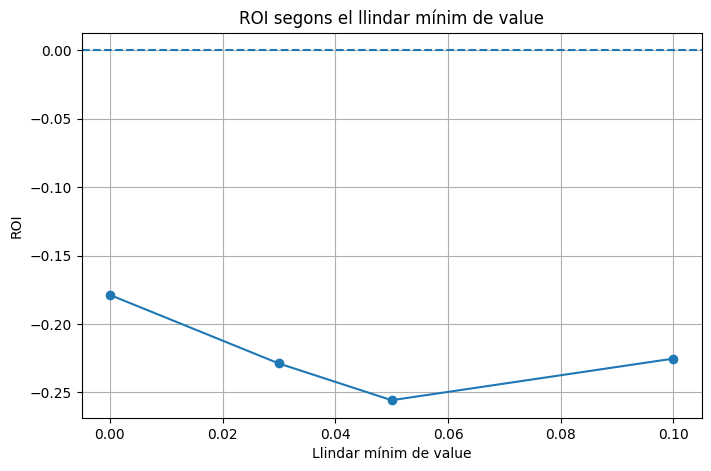

In [51]:
plt.figure(figsize=(8,5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["ROI"],
    marker="o"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Llindar mínim de value")
plt.ylabel("ROI")
plt.title("ROI segons el llindar mínim de value")

plt.grid()

plt.show()